In [25]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('/home/chunyang/projects/ACDM4SCIENCE/data/foil_slice/foilslice_10.csv')

In [27]:
df.head()

,TimeStep,Time,Velocity:0,Velocity:1,Velocity:2,Velocity Magnitude,Pressure,Temperature,Points:0,Points:1,Points:2
0,10,0.00107,7129.2,-2111.20,1276.50,7544.0,7280700.0,-634950.0,535.97,200,3.95350
1,10,0.00107,7819.2,-1432.60,4036.90,8915.8,-184180.0,-740020.0,535.61,200,1.71220
2,10,0.00107,5586.4,-3258.90,2162.40,6819.5,1483900.0,-3735300.0,534.89,200,2.76440
3,10,0.00107,6067.8,-2985.40,878.81,6819.3,5556700.0,-3347300.0,534.53,200,3.27980
4,10,0.00107,10026.0,224.84,2307.60,10291.0,4306800.0,-89752.0,536.02,200,-0.87047


In [28]:
v = df.iloc[:, 5]
x = df.iloc[:, 8]
y = df.iloc[:, 10]

In [29]:
x_min, x_max = min(x), max(x)
y_min, y_max = min(y), max(y)
grid_num = (1024, 1024)

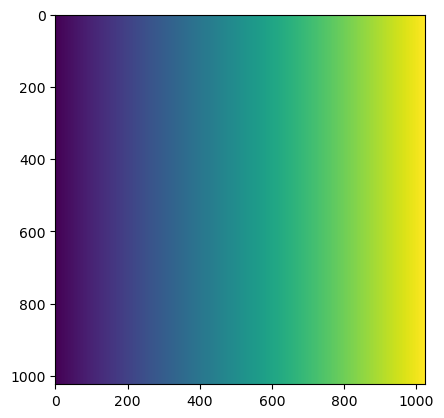

In [30]:
x_coord, y_coord = np.meshgrid(np.linspace(x_min, x_max, grid_num[0]), np.linspace(y_min, y_max, grid_num[1]))
plt.imshow(x_coord)
plt.show()
x_coord, y_coord = x_coord.flatten(), y_coord.flatten()

In [31]:
v_interpolate = scipy.interpolate.griddata((x, y), v, (x_coord, y_coord)).reshape(grid_num)

In [36]:
v_interpolate

array([[10000.        ,  9887.10920026,  9774.21840052, ...,
         9392.7       ,  9392.7       ,  9392.7       ],
       [10000.        ,  9887.01559145,  9774.08976571, ...,
         9392.7       ,  9392.7       ,  9392.7       ],
       [10000.        ,  9886.95700863,  9774.03118289, ...,
         9392.7       ,  9392.7       ,  9392.7       ],
       ...,
       [10000.        ,  9886.92789207,  9774.02942948, ...,
         9396.8       ,  9396.8       ,  9396.8       ],
       [10000.        ,  9887.01471474,  9774.20180257, ...,
         9396.8       ,  9396.8       ,  9396.8       ],
       [           nan,            nan,            nan, ...,
         9396.8       ,  9396.8       ,  9396.8       ]])

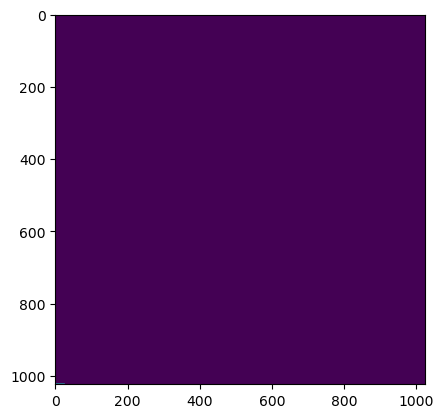

In [34]:
plt.imshow(np.isnan(v_interpolate))

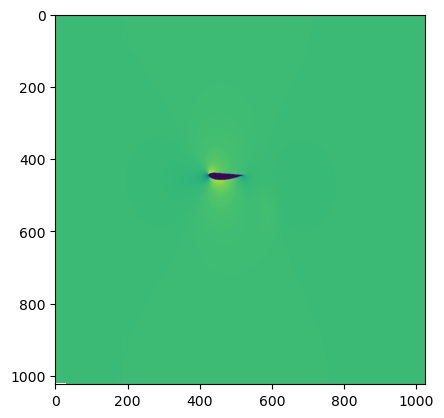

In [33]:
plt.imshow(v_interpolate)

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import logging
import copy
import numpy as np

import math
import os, json
from typing import List,Tuple,Dict

import sys

sys.path.append(os.path.abspath('../ai4flow/acdm'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion
from functools import partial
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
# import seaborn as sns

from turbpred.foilslice_dataset import FoilsliceDataset, Transforms


device = "cuda:0" if torch.cuda.is_available() else "cpu"

/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

testSet = FoilsliceDataset(name="foilslice dataset",
                     dataDir="/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed",
                     idx_range=[1500, 1900],
                     sequenceLength=[1, 1], rey=1000)

Loading data from 	 /home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed
Loading completed. Files loaded: 	400
Loading completed. Files loaded: 	400

Dataset info detail:
	 Sequence length of each sample: 1
	 Sequence skiping samples of: 1


In [18]:
d = testSet[0]["data"][0, 1, :, :]
d.shape

(128, 64)

In [38]:
d

array([[-244.27787935, -248.80932269, -253.12532279, ...,  355.07552648,
         351.6354931 ,  346.40290569],
       [-251.86484176, -256.43361886, -261.63405105, ...,  360.86991508,
         357.65338163,  352.2122225 ],
       [-259.12296668, -264.58982147, -270.15011211, ...,  366.83201635,
         363.47880707,  358.0549074 ],
       ...,
       [-254.31096908, -253.84203691, -264.46181927, ...,   17.63150097,
          36.98194864,   56.16270213],
       [-256.26711031, -232.03794303, -220.08544898, ...,   20.4679621 ,
          39.73062809,   57.96230482],
       [-249.0172707 , -224.78810342, -227.25819646, ...,   22.14797047,
          41.11142692,   58.97640727]])

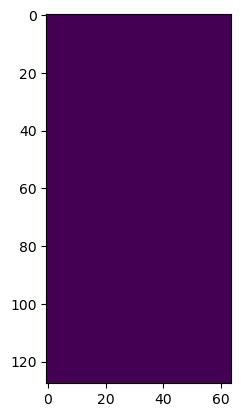

In [19]:
plt.imshow(np.isnan(d))

In [20]:
testSet[0]["path"]

['/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed/foilslice_01500.npy']

In [21]:
dd = np.load('/home/chunyang/projects/DDPM4SCIENCE/data/foil_slice_processed/foilslice_01500.npy')

In [23]:
ddd = dd[0, :, :]

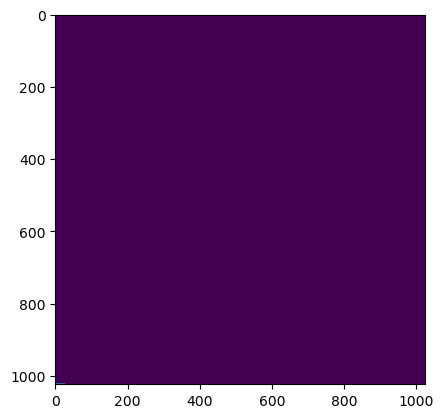

In [24]:
plt.imshow(np.isnan(ddd))